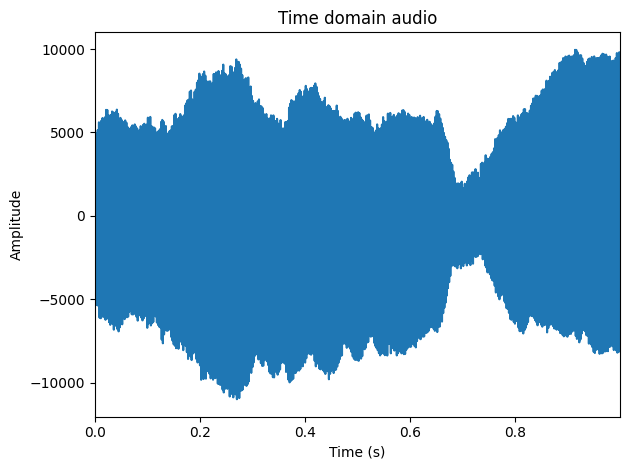

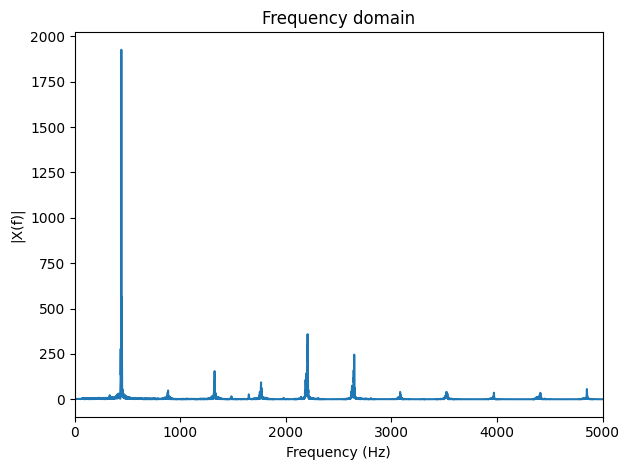

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# --- Carregar arquivo de áudio ---
# Substitua pelo caminho do seu arquivo .wav
fs, data = wavfile.read("1_violin.wav")

# Se for estéreo, converte para mono
if data.ndim > 1:
    data = data.mean(axis=1)

data = data[:fs] # fs amostras correspondem a 1 segundo
N = len(data)
t = np.arange(N) / fs

# --- FFT (espectro de magnitude) ---
fft_vals = np.fft.rfft(data)
freqs = np.fft.rfftfreq(N, d=1 / fs)
magnitude = np.abs(fft_vals) / N

# --- Plot no domínio do tempo ---
plt.figure()
plt.title("Time domain audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.plot(t, data)
plt.xlim(0, min(1, t[-1]))  # mostra 50 ms para facilitar
plt.tight_layout()
plt.show()

# --- Plot no domínio da frequência ---
plt.figure()
plt.title("Frequency domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X(f)|")
plt.plot(freqs, magnitude)
plt.xlim(0, 5000)  # mostra até 5 kHz
plt.tight_layout()
plt.show()